---
---

<table align="center" style="border-collapse: collapse; border: none; width: 100%;">
  <tr>
    <td style="border: none; width: 15%;">
      <img src="https://raw.githubusercontent.com/SouthPoleTelescope/spt_candl_data/main/logos/spt_logo.jpg" alt="SPT Logo" style="width: 100%; height: auto;">
    </td>
    <td style="border: none; text-align: center; vertical-align: middle; padding: 0 30px; width: 50%;">
      <span style="font-size: 4vw; font-weight: bold;">SPT-3G Ext-10k T&E forecasts</span>
    </td>
    <td style="border: none; width: 15%;">
      <img src="https://raw.githubusercontent.com/SouthPoleTelescope/spt_candl_data/main/logos/candl_logo.png" alt="CANDL Logo" style="width: 100%; height: auto;">
    </td>
  </tr>
</table>

---
---

This small tutorial introduces you to working with SPT-3G Ext-10k T&E mock data in `candl`. `candl` is a python-based, differentiable CMB likelihood code designed to make analysis easier and more flexible. This tutorial covers the basics necessary to compute the T&E Ext-10k Fisher matrix.

In [44]:
# Necessary imports and setup
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib.colors as colors
%matplotlib inline

import candl
import candl.likelihood
import candl.interface
import candl.tools

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [45]:
# Initialize candl likelihoods for the 13 fields which compose the Ext-10k survey
surveys = ["Main","Summer","Wide"]
Summer_fields = ["a","b","c"]
Wide_fields = ["a","b","c","d","e","f","g","h","i"]

Ext10k_likelihoods_list = []
for survey in surveys:
    if survey == "Main":
        Main_likelihood = candl.Like("../spt_candl_forecasts/SPT3G_Main_TnE_v0/SPT3G_Main_TnE.yaml")
        Ext10k_likelihoods_list += [Main_likelihood]
    else:
        if survey == "Summer":
            fields_list = Summer_fields.copy()
        else:
            fields_list = Wide_fields.copy()
        for i, field in enumerate(fields_list):
            Ext10k_likelihoods_list += [candl.Like("../spt_candl_forecasts/SPT3G_{}_{}_TnE_v0/SPT3G_{}_{}_TnE.yaml".format(survey,field,survey,field))]

Successfully initialised candl likelihood 'SPT-3G Main 5 years TnE' (type: <class 'candl.likelihood.Like'>).
Data loaded from '../spt_candl_forecasts/SPT3G_Main_TnE_v0/'.
Functional likelihood form: gaussian
--------------------------------------------------------------------------------
It will analyse the following spectra:

TT 90x90     (73 bins, bin centres spanning ell = 375.0 - 3974.5)
TE 90x90     (73 bins, bin centres spanning ell = 374.9 - 3974.5)
EE 90x90     (73 bins, bin centres spanning ell = 374.8 - 3974.5)
TT 90x150    (73 bins, bin centres spanning ell = 375.0 - 3974.5)
TE 90x150    (73 bins, bin centres spanning ell = 374.9 - 3974.5)
EE 90x150    (73 bins, bin centres spanning ell = 374.8 - 3974.5)
TT 90x220    (73 bins, bin centres spanning ell = 375.0 - 3974.5)
TE 90x220    (73 bins, bin centres spanning ell = 374.9 - 3974.5)
EE 90x220    (73 bins, bin centres spanning ell = 374.8 - 3974.5)
TT 150x150   (73 bins, bin centres spanning ell = 375.0 - 3974.5)
TE 150x150 

In [46]:
# Load CosmoPower emulators
cp_emulator_filenames = {"TT": "cmb_lcdm_spt_TT_NN.npz",
                         "TE": "cmb_lcdm_spt_TE_PCAplusNN.npz",
                         "EE": "cmb_lcdm_spt_EE_NN.npz"}
pars_to_theory_specs = candl.interface.get_CosmoPowerJAX_pars_to_theory_specs_func(cp_emulator_filenames)

# Define fiducial cosmological parameters
pars = {'H0': 67.37,
        'ombh2': 0.02233,
        'omch2': 0.1198,
        'logA': 3.043,
        'ns': 0.9652,
        'tau': 0.054}

# Add nuisance parameters 
pars_foregrounds = pars.copy()
for par in Main_likelihood.required_nuisance_parameters:
    for prior in Main_likelihood.priors:
        if par in prior.par_names:
            pars_foregrounds[par] = prior.central_value[prior.par_names.index(par)]
print("\n", pars_foregrounds)

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, if case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, if case this also fails or does not output the right shape make sure you r

In [47]:
# Compute Ext-10k Fisher matrix
Ext10k_Fisher = 0

for i, field_likelihood in enumerate(Ext10k_likelihoods_list):
    Fisher_mat, par_order_list = candl.tools.get_fisher_matrix(pars_to_theory_specs, 
                                                               field_likelihood, 
                                                               pars_foregrounds, 
                                                               return_par_order=True, 
                                                               return_par_cov=False)
    Ext10k_Fisher += Fisher_mat

# Compute Ext-10k parameter covariance matrix
Ext10k_parCov = inv(Ext10k_Fisher)
Ext10k_parCov_cosmo = Ext10k_parCov[0:6,0:6]

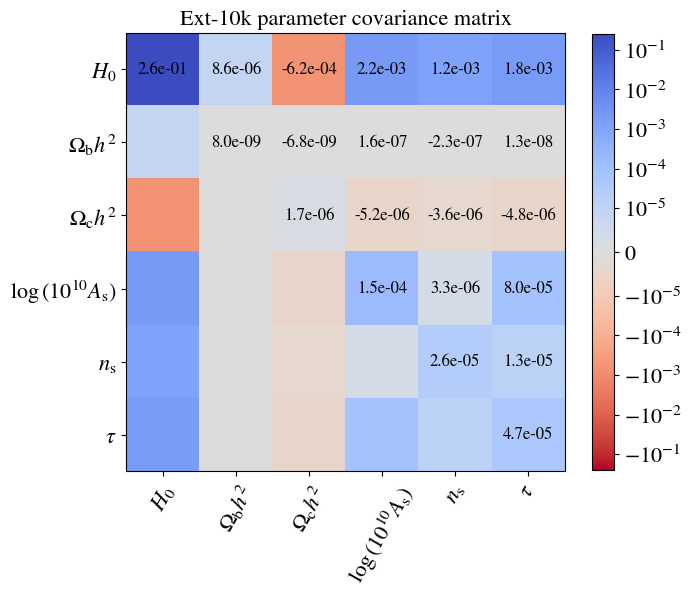

In [54]:
# Plot the Ext-10k parameter covariance matrix
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(Ext10k_parCov_cosmo,
               norm=colors.SymLogNorm(linthresh=1.e-5,
                                      vmin=-Ext10k_parCov_cosmo.max(),
                                      vmax=Ext10k_parCov_cosmo.max()), 
               cmap="coolwarm_r")
fig.colorbar(im,shrink=0.72).ax.tick_params(labelsize=16)

new_labels = [r"$H_0$",r"$\Omega_{\mathrm{b}}h^2$",r"$\Omega_{\mathrm{c}}h^2$",r"$\log{(10^{10} A_{\mathrm{s}})}$",r"$n_{\mathrm{s}}$",r"$\tau$"]
ax.set_xticks(np.arange(0,6), labels=new_labels, fontsize=16, rotation=60)
ax.set_yticks(np.arange(0,6), labels=new_labels, fontsize=16)
for i in range(0,6):
    for j in range(i,6):
        text = ax.text(j, i, 
                       "{:.1e}".format(Ext10k_parCov_cosmo[i, j]),
                       ha="center", 
                       va="center", 
                       color="k",
                       fontsize=12)

ax.set_title("Ext-10k parameter covariance matrix", fontsize=16)
fig.tight_layout()
plt.show()